### PHASE 1 : PREPROCESSING
* BCI Competition IV Dataset 2a
* Channels: All 22 channels
* All subjects: A01, A02, A03, A04, A05, A06, A07, A08, A09


In [1]:
import warnings
import mne
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import scipy.io

warnings.filterwarnings(
    "ignore",
    message="Could not determine channel type of the following channels, they will be set as EEG:*"
 )

Final Train EEG shape: (1294, 22, 1001)
Final Train labels shape: (1294,)
Final Test EEG shape: (1295, 22, 1001)
Final Test labels shape: (1295,)


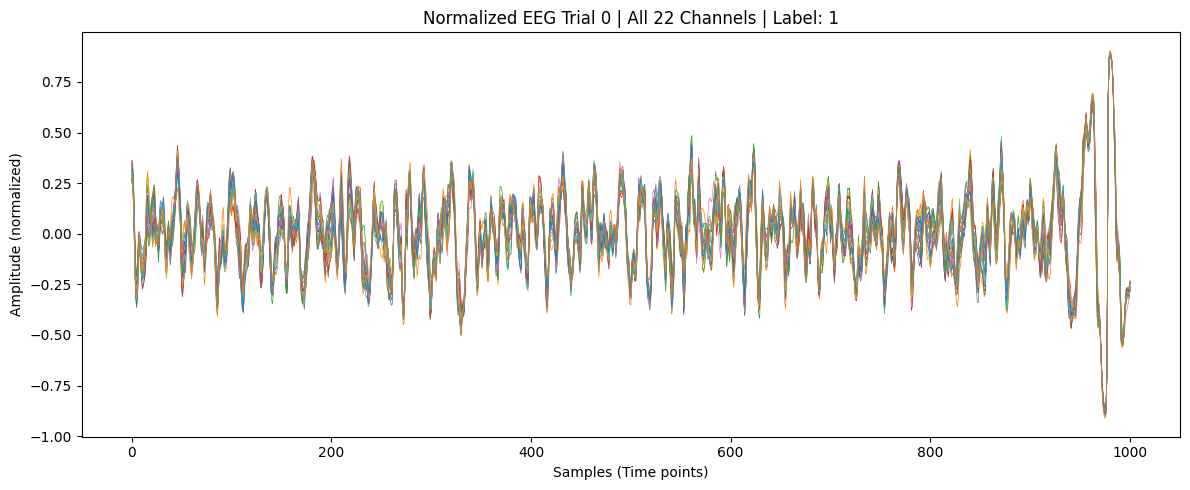

In [2]:
# Preprocessing both Train (T) and Test (E) files

def load_and_preprocess(run_type="T"):
    all_X = []
    all_y = []

    # Loop through subjects 1 to 9
    for subject in range(1, 10):
        # A01T.gdf / A01E.gdf, etc.
        file_path = f"BCICIV_2a_gdf/A{subject:02d}{run_type}.gdf"

        # Load EEG recording
        raw = mne.io.read_raw_gdf(file_path, preload=True, verbose="ERROR")

        # If it's test/evaluation set, replace '783' annotations with actual labels from mat file
        if run_type == "E":
            mat_path = file_path.replace(".gdf", ".mat")
            mat_data = scipy.io.loadmat(mat_path)
            classlabel = mat_data['classlabel'].flatten() # array of shape (288,)
            
            # Map mat class labels (1, 2, 3, 4) to GDF annotation strings
            label_map = {1: '769', 2: '770', 3: '771', 4: '772'}
            test_annotations = [label_map[lbl] for lbl in classlabel]
            
            # Replace '783' annotations in raw
            descriptions = raw.annotations.description.copy()
            idx = 0
            for i, desc in enumerate(descriptions):
                if desc == '783':
                    descriptions[i] = test_annotations[idx]
                    idx += 1
            raw.annotations.description = descriptions

        # Explicitly mark known EOG channels when present
        eog_channels = ["EOG-left", "EOG-central", "EOG-right"]
        present_eog = {ch: "eog" for ch in eog_channels if ch in raw.ch_names}
        if present_eog:
            raw.set_channel_types(present_eog)

        # Keeping all EEG channels (excluding EOG channels)
        eeg_channels = [ch for ch in raw.ch_names if ch.startswith("EEG")]
        raw.pick(eeg_channels)

        # Motor imagery frequency range (alpha, beta) bandpass filtering
        raw.filter(8, 30, verbose="ERROR")

        # Extract event markers
        events, event_dict = mne.events_from_annotations(raw, verbose="ERROR")

        # Keep only left hand ("769") and right hand ("770") events
        available_events = {
            k: v for k, v in event_dict.items()
            if k in ["769", "770"]
        }

        # Create trials from 2s to 6s after cue
        epochs = mne.Epochs(
            raw,
            events,
            event_id=available_events,
            tmin=2,
            tmax=6,
            baseline=None,
            preload=True,
            verbose="ERROR"
        )

        # EEG data
        X = epochs.get_data()

        # Labels
        y_label = epochs.events[:, 2]

        # Map MNE internal IDs for '769' (left) and '770' (right) to 0 and 1 remapping
        subject_label_map = {}
        if "769" in epochs.event_id:
            subject_label_map[epochs.event_id["769"]] = 0
        if "770" in epochs.event_id:
            subject_label_map[epochs.event_id["770"]] = 1
        y_label = np.vectorize(subject_label_map.get)(y_label).astype(np.int64)

        # Store current subject
        all_X.append(X)
        all_y.append(y_label)

    # Combine all subjects
    X_all = np.concatenate(all_X, axis=0)
    y_all = np.concatenate(all_y, axis=0)
    return X_all, y_all

# Preprocess both Train (T) and Test (E) files
X_train_raw, y_train = load_and_preprocess("T")
X_test_raw, y_test = load_and_preprocess("E")

# Normalize EEG values to [-1, 1]
scaler = MinMaxScaler(feature_range=(-1, 1))
X_train_flat = X_train_raw.reshape(-1, X_train_raw.shape[-1])
X_train_norm = scaler.fit_transform(X_train_flat).reshape(X_train_raw.shape)

X_test_flat = X_test_raw.reshape(-1, X_test_raw.shape[-1])
X_test_norm = scaler.transform(X_test_flat).reshape(X_test_raw.shape)

# Keep 'y' pointing to 'y_train' so that the next test/print cell doesn't break
y = y_train

# Save datasets
np.save("X_train_preprocessed.npy", X_train_norm)
np.save("y_train.npy", y_train)
np.save("X_test_preprocessed.npy", X_test_norm)
np.save("y_test.npy", y_test)

print("Final Train EEG shape:", X_train_norm.shape)
print("Final Train labels shape:", y_train.shape)
print("Final Test EEG shape:", X_test_norm.shape)
print("Final Test labels shape:", y_test.shape)

#  visualization: first trial, all 22 channels from training set
trial_idx = 0
plt.figure(figsize=(12, 5))
for ch_idx in range(X_train_norm.shape[1]):
    plt.plot(X_train_norm[trial_idx, ch_idx, :], linewidth=0.5)

plt.title(f"Normalized EEG Trial {trial_idx} | All 22 Channels | Label: {y_train[trial_idx]}")
plt.xlabel("Samples (Time points)")
plt.ylabel("Amplitude (normalized)")
plt.tight_layout()
plt.show()


### PHASE 2: DATA LOADING & Z-SCORE NORMALIZATION

In [3]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    DepthwiseConv2D,
    SeparableConv2D,
    AveragePooling2D,
    BatchNormalization,
    Activation,
    Dense,
    Dropout,
    Flatten
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.constraints import max_norm

In [4]:
print(np.unique(y, return_counts=True))

(array([0, 1]), array([646, 648]))


In [5]:
# STEP 1: LOADING DATA

X_train = np.load("X_train_preprocessed.npy")
y_train = np.load("y_train.npy")
X_test = np.load("X_test_preprocessed.npy")
y_test = np.load("y_test.npy")

print("Loaded Train EEG data (Binary: Left vs Right)")
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("Class distribution:", np.unique(y_train, return_counts=True))

print("Loaded Test EEG data (Binary: Left vs Right)")
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)
print("Class distribution:", np.unique(y_test, return_counts=True))

# Per-trial, per-channel z-score normalization works better than a global min-max scale
# for CNNs on EEG because it preserves local trial dynamics.
X_train = X_train.astype(np.float32)
X_train = (X_train - X_train.mean(axis=2, keepdims=True)) / (X_train.std(axis=2, keepdims=True) + 1e-8)
X_train = np.nan_to_num(X_train)

X_test = X_test.astype(np.float32)
X_test = (X_test - X_test.mean(axis=2, keepdims=True)) / (X_test.std(axis=2, keepdims=True) + 1e-8)
X_test = np.nan_to_num(X_test)

# EEGNet-style 2D CNN expects an explicit singleton spatial dimension.
# Shape becomes: samples x channels x time x 1
X_train = X_train[..., np.newaxis]
X_test = X_test[..., np.newaxis]

print("CNN Train Input Shape:", X_train.shape)
print("CNN Test Input Shape:", X_test.shape)


Loaded Train EEG data (Binary: Left vs Right)
X_train shape: (1294, 22, 1001)
y_train shape: (1294,)
Class distribution: (array([0, 1]), array([646, 648]))
Loaded Test EEG data (Binary: Left vs Right)
X_test shape: (1295, 22, 1001)
y_test shape: (1295,)
Class distribution: (array([0, 1]), array([647, 648]))
CNN Train Input Shape: (1294, 22, 1001, 1)
CNN Test Input Shape: (1295, 22, 1001, 1)


### PHASE 3: CONDITIONAL WGAN-GP DEVELOPMENT

Implementing Conditional Wasserstein GAN with Gradient Penalty (WGAN-GP) to generate synthetic EEG data for the two motor imagery classes: Left Hand (0) and Right Hand (1).
- Both Generator and Critic use 1D convolutional layers.
- Generator upsamples using bilinear interpolation to prevent high-frequency checkerboard artifacts.
- To run efficiently on CPU, i am using a compact convolutional design with kernel size 7.
- Training runs with gradient penalty constraint.

critic loss :
- Very large negative  → Critic is much stronger than Generator
- Closer to zero       → Real and fake distributions are becoming similar

In [6]:
import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.layers import Input, Dense, Reshape, Conv1D, Embedding, Flatten, Concatenate, Lambda, LeakyReLU
import numpy as np

In [7]:
# STEP 1: PREPARE DATA FOR WGAN-GP

# Transpose z-score normalized X_train from shape (samples, channels, time) to (samples, time, channels) for 1D CNN
X_real_gan = np.transpose(X_train[..., 0], (0, 2, 1)) # shape: (1294, 1001, 22)
X_real_gan = X_real_gan.astype(np.float32) # Ensure data type is float32 to avoid TF type mismatch
print("WGAN-GP Real Input Shape:", X_real_gan.shape)

# Training Hyperparameters
latent_dim = 100    # The size of the random noise vector (generator seed).
gp_weight = 10.0
n_critic = 5
batch_size = 64
# epochs = 15  # Set to 15 for fast CPU execution; on a GPU machine, set to 500+ for best results
epochs = 100

# STEP 2: DEFINE GENERATOR & CRITIC
def resize_1d(x, new_length):
    # Interpolation-based upsampling
    x_4d = tf.expand_dims(x, axis=2)
    x_resized = tf.image.resize(x_4d, [new_length, 1], method='bilinear')
    return tf.squeeze(x_resized, axis=2)

def make_generator():
    noise_in = Input(shape=(latent_dim,))
    label_in = Input(shape=(1,), dtype='int32')
    
    label_emb = Embedding(input_dim=2, output_dim=50)(label_in)
    label_emb = Flatten()(label_emb)
    
    x = Concatenate()([noise_in, label_emb])
    x = Dense(125 * 64, activation='relu')(x)
    x = Reshape((125, 64))(x)
    x = Conv1D(64, kernel_size=7, padding='same', activation='relu')(x)
    
    x = Lambda(lambda t: resize_1d(t, 250))(x)
    x = Conv1D(64, kernel_size=7, padding='same', activation='relu')(x)
    
    x = Lambda(lambda t: resize_1d(t, 500))(x)
    x = Conv1D(32, kernel_size=7, padding='same', activation='relu')(x)
    
    x = Lambda(lambda t: resize_1d(t, 1001))(x)
    x_out = Conv1D(22, kernel_size=7, padding='same')(x) # Output 22 channels (all channels)
    
    return Model([noise_in, label_in], x_out, name="Generator")

def make_critic():
    eeg_in = Input(shape=(1001, 22)) # Input shape with 22 channels
    label_in = Input(shape=(1,), dtype='int32')
    
    label_emb = Embedding(input_dim=2, output_dim=50)(label_in)
    label_emb = Dense(1001)(label_emb)
    label_emb = Reshape((1001, 1))(label_emb)
    
    x = Concatenate(axis=-1)([eeg_in, label_emb])
    
    x = Conv1D(32, kernel_size=7, strides=2, padding='same')(x)
    x = LeakyReLU(0.2)(x)
    x = Conv1D(64, kernel_size=7, strides=2, padding='same')(x)
    x = LeakyReLU(0.2)(x)
    x = Conv1D(128, kernel_size=7, strides=2, padding='same')(x)
    x = LeakyReLU(0.2)(x)
    
    x = Flatten()(x)
    x_out = Dense(1)(x)
    
    return Model([eeg_in, label_in], x_out, name="Critic")

generator = make_generator()
critic = make_critic()

critic_optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4, beta_1=0.5, beta_2=0.9)
gen_optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4, beta_1=0.5, beta_2=0.9)

# STEP 3: CUSTOM WGAN-GP TRAINING LOOP
@tf.function
def train_step(real_eeg, labels):
    for _ in range(n_critic):
        noise = tf.random.normal([batch_size, latent_dim])
        with tf.GradientTape() as critic_tape:
            fake_eeg = generator([noise, labels], training=True)
            d_real = critic([real_eeg, labels], training=True)
            d_fake = critic([fake_eeg, labels], training=True)
            
            epsilon = tf.random.uniform([batch_size, 1, 1], 0.0, 1.0)
            interpolated = epsilon * real_eeg + (1 - epsilon) * fake_eeg
            with tf.GradientTape() as gp_tape:
                gp_tape.watch(interpolated)
                d_hat = critic([interpolated, labels], training=True)
            
            gradients = gp_tape.gradient(d_hat, interpolated)
            norms = tf.sqrt(tf.reduce_sum(tf.square(gradients), axis=[1, 2]) + 1e-12)
            gp = tf.reduce_mean((norms - 1.0) ** 2)
            critic_loss = tf.reduce_mean(d_fake) - tf.reduce_mean(d_real) + gp_weight * gp

        gradients_critic = critic_tape.gradient(critic_loss, critic.trainable_variables)
        critic_optimizer.apply_gradients(zip(gradients_critic, critic.trainable_variables))
        
    noise = tf.random.normal([batch_size, latent_dim])
    with tf.GradientTape() as gen_tape:
        fake_eeg = generator([noise, labels], training=True)
        d_fake = critic([fake_eeg, labels], training=True)
        gen_loss = -tf.reduce_mean(d_fake)
        
    gradients_gen = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gen_optimizer.apply_gradients(zip(gradients_gen, generator.trainable_variables))
    
    return critic_loss, gen_loss

print("Training Conditional WGAN-GP...")

dataset = tf.data.Dataset.from_tensor_slices((X_real_gan, y_train)).shuffle(len(y_train)).batch(batch_size, drop_remainder=True)

for epoch in range(epochs):
    c_losses = []
    g_losses = []
    for real_batch, labels_batch in dataset:
        labels_batch = tf.expand_dims(labels_batch, axis=-1)
        c_loss, g_loss = train_step(real_batch, labels_batch)
        c_losses.append(c_loss)
        g_losses.append(g_loss)
    
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:03d}/{epochs:03d} | Critic Loss: {np.mean(c_losses):.4f} | Generator Loss: {np.mean(g_losses):.4f}")


WGAN-GP Real Input Shape: (1294, 1001, 22)

Training Conditional WGAN-GP...
Epoch 001/100 | Critic Loss: -124.6205 | Generator Loss: -11.8946
Epoch 005/100 | Critic Loss: -577.8895 | Generator Loss: -37.0407
Epoch 010/100 | Critic Loss: -297.6347 | Generator Loss: -94.0630
Epoch 015/100 | Critic Loss: -211.0201 | Generator Loss: -128.7304
Epoch 020/100 | Critic Loss: -192.5064 | Generator Loss: -254.4330
Epoch 025/100 | Critic Loss: -184.5842 | Generator Loss: -469.0075
Epoch 030/100 | Critic Loss: -171.3594 | Generator Loss: -344.1874
Epoch 035/100 | Critic Loss: -172.2730 | Generator Loss: -374.2759
Epoch 040/100 | Critic Loss: -156.6721 | Generator Loss: -297.5913
Epoch 045/100 | Critic Loss: -129.0125 | Generator Loss: -218.9585
Epoch 050/100 | Critic Loss: -104.8987 | Generator Loss: -213.6982
Epoch 055/100 | Critic Loss: -95.8063 | Generator Loss: -264.7039
Epoch 060/100 | Critic Loss: -90.3383 | Generator Loss: -263.0076
Epoch 065/100 | Critic Loss: -87.1982 | Generator Loss: -2

### PHASE 4: SYNTHETIC DATA EVALUATION

Verifying the quality of generated EEG data in both the time and frequency domains, and calculate quantitative similarity metrics.
- SWD (closer to 0 is better)
- Pearson correlation (closer to 1 is better)

Generated synthetic EEG shape: (1294, 22, 1001)


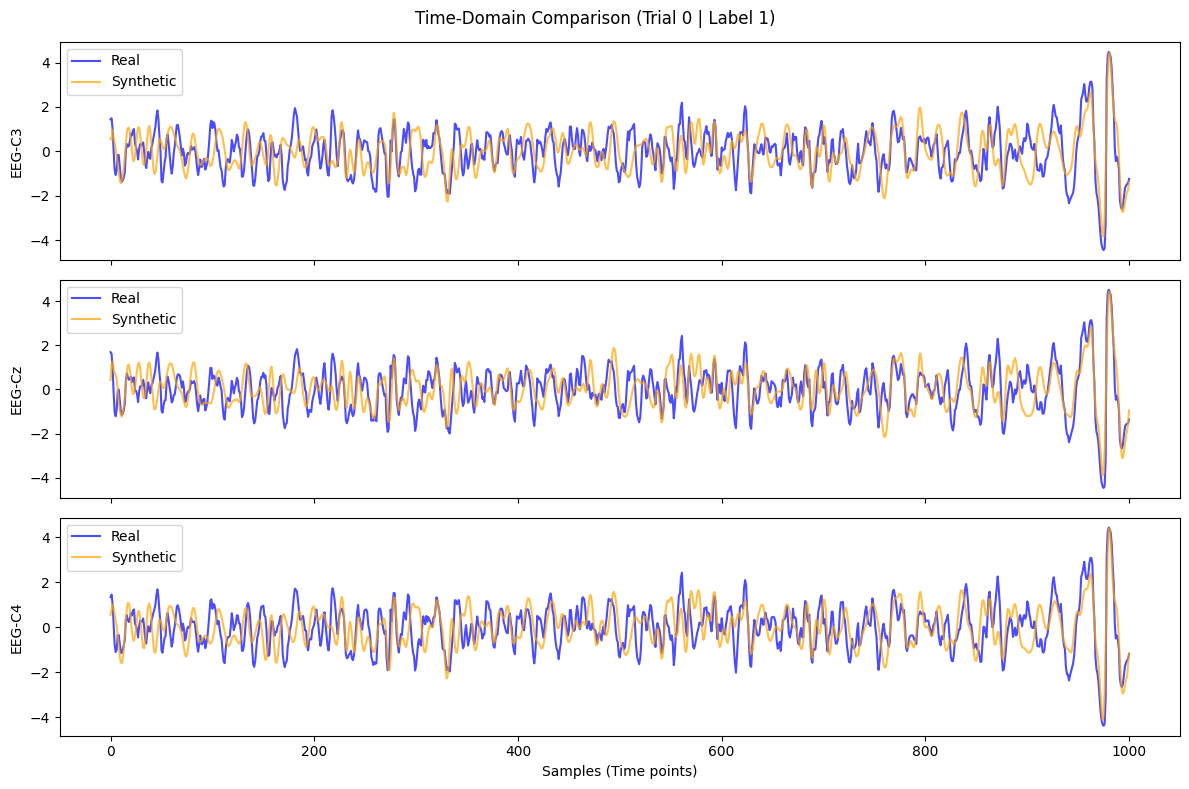

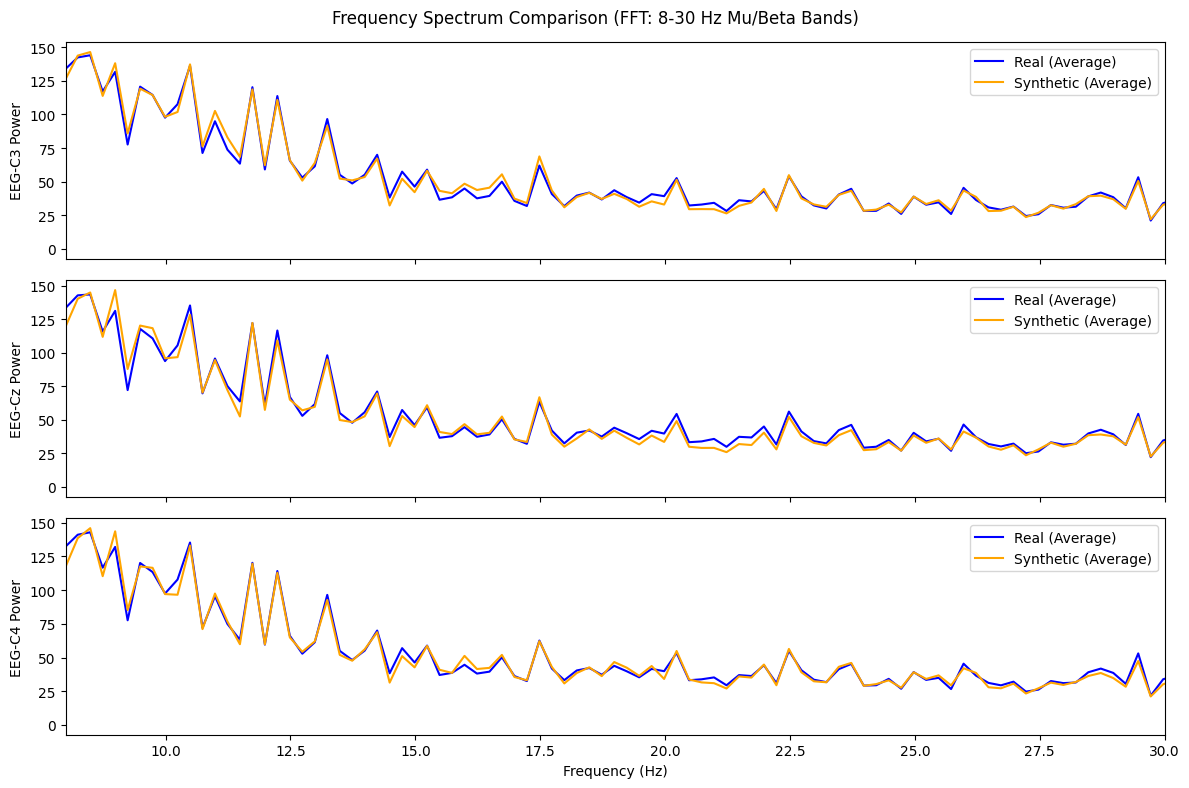

Calculating similarity metrics...
Pearson Correlation per channel (C3, Cz, C4): [np.float32(0.9546), np.float32(0.9562), np.float32(0.9551)]
Sliced Wasserstein Distance (SWD): 0.1978


In [8]:
# STEP 1: GENERATE SYNTHETIC DATA
noise = np.random.normal(size=(len(y_train), latent_dim)).astype(np.float32)
y_fake = y_train.copy()
synthetic_raw = generator.predict([noise, y_fake[:, np.newaxis]], verbose=0)

# Transpose back to (samples, channels, time) format
X_fake = np.transpose(synthetic_raw, (0, 2, 1))
print("Generated synthetic EEG shape:", X_fake.shape)

# STEP 2: TIME DOMAIN PLOTS
import matplotlib.pyplot as plt
import scipy.stats

trial_idx = 0
channels = ["EEG-C3", "EEG-Cz", "EEG-C4"]

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
for ch_idx, ch_name in enumerate(channels):
    axes[ch_idx].plot(X_train[trial_idx, ch_idx, :, 0], label="Real", color="blue", alpha=0.7)
    axes[ch_idx].plot(X_fake[trial_idx, ch_idx, :], label="Synthetic", color="orange", alpha=0.7)
    axes[ch_idx].set_ylabel(ch_name)
    axes[ch_idx].legend()

axes[2].set_xlabel("Samples (Time points)")
plt.suptitle(f"Time-Domain Comparison (Trial {trial_idx} | Label {y_train[trial_idx]})")
plt.tight_layout()
plt.show()

# STEP 3: FREQUENCY SPECTRA PLOTS (FFT) - How much of each frequency is present in the EEG signal?
sfreq = 250
freqs = np.fft.rfftfreq(1001, d=1/sfreq)    # Fast Fourier Transform -> converts time-domain values to frequency components

real_fft = np.abs(np.fft.rfft(X_train[..., 0], axis=2))
fake_fft = np.abs(np.fft.rfft(X_fake, axis=2))

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
for ch_idx, ch_name in enumerate(channels):
    axes[ch_idx].plot(freqs, real_fft.mean(axis=0)[ch_idx, :], label="Real (Average)", color="blue")
    axes[ch_idx].plot(freqs, fake_fft.mean(axis=0)[ch_idx, :], label="Synthetic (Average)", color="orange")
    axes[ch_idx].set_xlim(8, 30) # Focus on Mu and Beta bands
    axes[ch_idx].set_ylabel(f"{ch_name} Power")
    axes[ch_idx].legend()

axes[2].set_xlabel("Frequency (Hz)")
plt.suptitle("Frequency Spectrum Comparison (FFT: 8-30 Hz Mu/Beta Bands)")
plt.tight_layout()
plt.show()

# STEP 4: QUANTITATIVE METRICS
print("Calculating similarity metrics...")

# Pearson Correlation
pearson_coeffs = []
for ch in range(3):
    avg_real = np.mean(X_train[:, ch, :, 0], axis=0)
    avg_fake = np.mean(X_fake[:, ch, :], axis=0)
    r, _ = scipy.stats.pearsonr(avg_real, avg_fake)
    pearson_coeffs.append(r)

print(f"Pearson Correlation per channel (C3, Cz, C4): {[round(x, 4) for x in pearson_coeffs]}")

# Sliced Wasserstein Distance (SWD)
def sliced_wasserstein_distance(X_real_data, X_fake_data, n_projections=50):
    N_real = X_real_data.shape[0]
    N_fake = X_fake_data.shape[0]
    real_flat = X_real_data.reshape(N_real, -1)
    fake_flat = X_fake_data.reshape(N_fake, -1)
    dim = real_flat.shape[1]
    
    swd_sum = 0.0
    for _ in range(n_projections):
        proj = np.random.normal(size=(dim,))
        proj /= np.linalg.norm(proj)
        p_real = np.dot(real_flat, proj)
        p_fake = np.dot(fake_flat, proj)
        swd_sum += scipy.stats.wasserstein_distance(p_real, p_fake)
    return swd_sum / n_projections

swd_score = sliced_wasserstein_distance(X_train[..., 0], X_fake)
print(f"Sliced Wasserstein Distance (SWD): {swd_score:.4f}")


### PHASE 5: DATA AUGMENTATION & FINAL TESTING

Evaluating the impact of synthetic EEG data augmentation by training the baseline CNN architecture on the augmented dataset (Real + Synthetic) and performing evaluation on Test data.

In [9]:
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, BatchNormalization, Activation, AveragePooling2D, Dropout, Flatten, Dense
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.constraints import max_norm
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

In [10]:
# STEP 1: PREPARE AUGMENTED DATASETS USING AN EXPLICIT SPLIT FOR VALIDATION
# To prevent early stopping artifacts caused by validating on low-quality synthetic data,
# we use the exact same validation split of REAL training data that the baseline model uses.
val_size = int(len(X_train) * 0.2)
train_size = len(X_train) - val_size

X_train_real = X_train[:train_size]
y_train_real = y_train[:train_size]
X_val_real = X_train[train_size:]
y_val_real = y_train[train_size:]

# Generate synthetic samples specifically for the training portion size
noise_train = np.random.normal(size=(train_size, latent_dim)).astype(np.float32)
y_fake_train = y_train_real.copy()
synthetic_raw_train = generator.predict([noise_train, y_fake_train[:, np.newaxis]], verbose=0)
X_fake_train = np.transpose(synthetic_raw_train, (0, 2, 1))[..., np.newaxis] # Shape (train_size, 22, 1001, 1)

# Augmented training set (Real Train Portion + Synthetic Train Portion)
X_aug = np.concatenate([X_train_real, X_fake_train], axis=0)
y_aug = np.concatenate([y_train_real, y_fake_train], axis=0)

# Shuffle the augmented training portion
shuffle_idx = np.random.permutation(len(X_aug))
X_aug = X_aug[shuffle_idx]
y_aug = y_aug[shuffle_idx]

print("Original Train Portion shape:", X_train_real.shape)
print("Augmented Train Portion shape:", X_aug.shape)
print("Real Validation Portion shape:", X_val_real.shape)
print("Unseen Test EEG shape:", X_test.shape)

# STEP 2: HELPER FUNCTION TO TRAIN THE CNN
def train_cnn_classifier(X_train_data, y_train_data, X_val_data, y_val_data, name):
    class_labels = np.unique(y_train_data)
    class_weights = compute_class_weight(
        class_weight="balanced",
        classes=class_labels,
        y=y_train_data
    )
    class_weight_dict = dict(zip(class_labels, class_weights))
    
    # CNN model for classification and accuracy
    # Re-instantiate model to ensure identical architecture
    cnn_model = Sequential([
        Input(shape=X_train_data.shape[1:]),
        Conv2D(16, (1, 64), padding="same", use_bias=False),
        BatchNormalization(),
        DepthwiseConv2D((22, 1), use_bias=False, depth_multiplier=2, depthwise_constraint=max_norm(1.0)), # Updated to 22 channels
        BatchNormalization(),
        Activation("elu"),
        AveragePooling2D((1, 4)),
        Dropout(0.25),

        SeparableConv2D(32, (1, 16), padding="same", use_bias=False),
        BatchNormalization(),
        Activation("elu"),
        AveragePooling2D((1, 8)),
        Dropout(0.25),
     
        Flatten(),
        Dense(2, activation="softmax")
    ])
    
    cnn_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    
    callbacks = [
        EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4, min_lr=1e-5)
    ]
    
    print(f"\nTraining CNN Classifier: {name}...")
    cnn_model.fit(
        X_train_data,
        y_train_data,
        epochs=60,
        batch_size=64,
        validation_data=(X_val_data, y_val_data),
        class_weight=class_weight_dict,
        callbacks=callbacks,
        verbose=2
    )
    return cnn_model

# STEP 3: TRAIN CNN ON AUGMENTED DATASET (Real + Synthetic)
model_aug = train_cnn_classifier(X_aug, y_aug, X_val_real, y_val_real, "Augmented (Real + 1x Synthetic)")

# STEP 4: EVALUATE ON THE UNSEEN REAL TEST SET
preds_aug = np.argmax(model_aug.predict(X_test, verbose=0), axis=1)
acc_aug = accuracy_score(y_test, preds_aug)
prec_aug = precision_score(y_test, preds_aug, average="macro", zero_division=0)
rec_aug = recall_score(y_test, preds_aug, average="macro", zero_division=0)
f1_aug = f1_score(y_test, preds_aug, average="macro", zero_division=0)

print("\n" + "="*79)
print("AUGMENTED MODEL (Real + 1x Synthetic) RESULTS ON UNSEEN TEST SET")
print("="*79)
print(f"Accuracy :", acc_aug)
print(f"Precision:", prec_aug)
print(f"Recall   :", rec_aug)
print(f"F1 Score :", f1_aug)
print("\nClassification report:\n")
print(classification_report(y_test, preds_aug, digits=4, zero_division=0))
print("="*79 + "\n")


Original Train Portion shape: (1036, 22, 1001, 1)
Augmented Train Portion shape: (2072, 22, 1001, 1)
Real Validation Portion shape: (258, 22, 1001, 1)
Unseen Test EEG shape: (1295, 22, 1001, 1)

Training CNN Classifier: Augmented (Real + 1x Synthetic)...
Epoch 1/60
33/33 - 10s - 296ms/step - accuracy: 0.4990 - loss: 0.7360 - val_accuracy: 0.5039 - val_loss: 0.6928 - learning_rate: 0.0010
Epoch 2/60
33/33 - 8s - 250ms/step - accuracy: 0.5256 - loss: 0.7071 - val_accuracy: 0.5000 - val_loss: 0.6927 - learning_rate: 0.0010
Epoch 3/60
33/33 - 8s - 233ms/step - accuracy: 0.5589 - loss: 0.6848 - val_accuracy: 0.5116 - val_loss: 0.6918 - learning_rate: 0.0010
Epoch 4/60
33/33 - 7s - 224ms/step - accuracy: 0.5569 - loss: 0.6821 - val_accuracy: 0.5000 - val_loss: 0.6918 - learning_rate: 0.0010
Epoch 5/60
33/33 - 7s - 226ms/step - accuracy: 0.5951 - loss: 0.6622 - val_accuracy: 0.5155 - val_loss: 0.6908 - learning_rate: 0.0010
Epoch 6/60
33/33 - 7s - 225ms/step - accuracy: 0.6057 - loss: 0.6607 